<a href="https://colab.research.google.com/github/dibyadarshandash8934-dev/ml-research/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional, Input

data = {
    "Hours": [0.5, 1.7, 2.5, 3.0, 4.8, 5.5, 6.3, 7.8, 8.6, 9.9],
    "Scores": [10, 21, 32, 37, 52, 61, 72, 80, 88, 98]
}

df = pd.DataFrame(data)
print("Sample Data:\n", df.head())

X = df[['Hours']].values
y = df['Scores'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# ML Models
models = {
    "Linear Regression": LinearRegression(),
    "SVM": SVR(kernel='rbf', C=1.2, epsilon=0.2),
    "Random Forest": RandomForestRegressor(n_estimators=120, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', n_estimators=120, learning_rate=0.12, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=3),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {"MSE": mean_squared_error(y_test, preds), "R2": r2_score(y_test, preds)}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
nb = GaussianNB()
y_train_int = np.round(y_train)
nb.fit(X_train_scaled, y_train_int)
preds = nb.predict(X_test_scaled)
results["Naive Bayes (approx)"] = {"MSE": mean_squared_error(y_test, preds), "R2": r2_score(y_test, preds)}

#  MLP Regressor
mlp = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42)
mlp.fit(X_train, y_train)
preds = mlp.predict(X_test)
results["MLP (Sklearn)"] = {"MSE": mean_squared_error(y_test, preds), "R2": r2_score(y_test, preds)}

X_train_rnn = np.expand_dims(X_train, axis=1)
X_test_rnn = np.expand_dims(X_test, axis=1)

def build_and_train(model, name):
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_rnn, y_train, epochs=200, verbose=0)
    preds = model.predict(X_test_rnn).flatten()
    results[name] = {"MSE": mean_squared_error(y_test, preds), "R2": r2_score(y_test, preds)}

rnn = Sequential([Input(shape=(1,1)), SimpleRNN(32), Dense(1)])
build_and_train(rnn, "RNN")

lstm = Sequential([Input(shape=(1,1)), LSTM(32), Dense(1)])
build_and_train(lstm, "LSTM")

bilstm = Sequential([Input(shape=(1,1)), Bidirectional(LSTM(32)), Dense(1)])
build_and_train(bilstm, "BiLSTM")

gru = Sequential([Input(shape=(1,1)), GRU(32), Dense(1)])
build_and_train(gru, "GRU")

bigru = Sequential([Input(shape=(1,1)), Bidirectional(GRU(32)), Dense(1)])
build_and_train(bigru, "BiGRU")

print("\nModel Performance (MSE & R2):")
print(pd.DataFrame(results).T)

Sample Data:
    Hours  Scores
0    0.5      10
1    1.7      21
2    2.5      32
3    3.0      37
4    4.8      52
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step

Model Performance (MSE & R2):
                              MSE        R2
Linear Regression        3.599365  0.995249
SVM                    650.768424  0.140963
Random Forest           22.422292  0.970402
XGBoost                 88.494392  0.883184
KNN                     33.074074  0.956341
Naive Bayes (approx)    88.666667  0.882957
MLP (Sklearn)            6.714924  0.991136
RNN                   3133.234131 -3.135979
LSTM                  3261.658203 -3.305503
BiLSTM                2974.023438 -2.925816
GRU                   3160.642578 -3.172159
BiGRU                 2490.321045 -2.287311


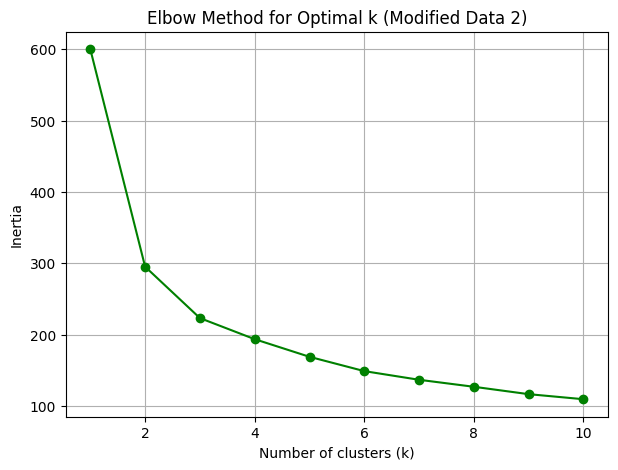

Silhouette Score (modified data 2): 0.307


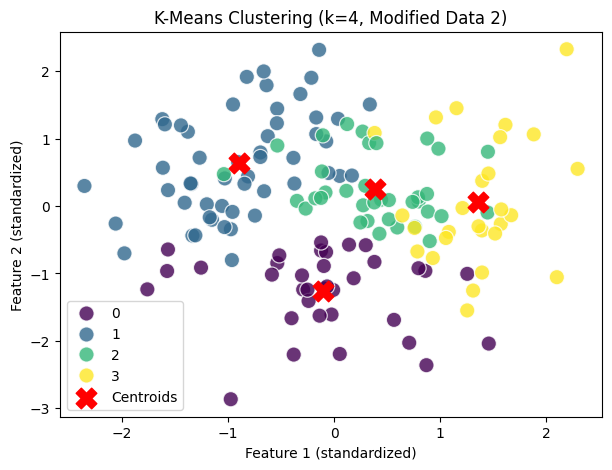

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

iris = load_iris()
X = iris.data.copy()
np.random.seed(7)
X = X + np.random.normal(0, 0.5, X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=20, max_iter=600, random_state=7)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='green')
plt.title("Elbow Method for Optimal k (Modified Data 2)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

k = 4
kmeans = KMeans(n_clusters=k, n_init=20, max_iter=600, random_state=7)
y_pred = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, y_pred)
print(f"Silhouette Score (modified data 2): {score:.3f}")

plt.figure(figsize=(7,5))
sns.scatterplot(x=X_scaled[:,0], y=X_scaled[:,1], hue=y_pred, palette="viridis", s=120, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], color='red', marker='X', s=220, label='Centroids')
plt.title("K-Means Clustering (k=4, Modified Data 2)")
plt.xlabel("Feature 1 (standardized)")
plt.ylabel("Feature 2 (standardized)")
plt.legend()
plt.show()


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, LSTM, GRU, Bidirectional
from tensorflow.keras.utils import to_categorical

iris = load_iris()
X = iris.data + np.random.normal(0, 0.3, iris.data.shape)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

ml_results = {}

models = {
    "Logistic Regression": LogisticRegression(max_iter=1200),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=7),
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=7)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    ml_results[name] = acc

dl_results = {}

mlp = MLPClassifier(hidden_layer_sizes=(80, 40), max_iter=2500, random_state=7)
mlp.fit(X_train, y_train)
preds = mlp.predict(X_test)
dl_results["MLP (Sklearn)"] = accuracy_score(y_test, preds)

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

X_train_rnn = np.expand_dims(X_train, axis=1)
X_test_rnn = np.expand_dims(X_test, axis=1)

def build_and_train(model, name):
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_rnn, y_train_cat, epochs=60, verbose=0)
    _, acc = model.evaluate(X_test_rnn, y_test_cat, verbose=0)
    dl_results[name] = acc

rnn = Sequential([
    Input(shape=(1, 4)),
    SimpleRNN(40),
    Dense(3, activation='softmax')
])
build_and_train(rnn, "RNN")

lstm = Sequential([
    Input(shape=(1, 4)),
    LSTM(40),
    Dense(3, activation='softmax')
])
build_and_train(lstm, "LSTM")

bilstm = Sequential([
    Input(shape=(1, 4)),
    Bidirectional(LSTM(40)),
    Dense(3, activation='softmax')
])
build_and_train(bilstm, "BiLSTM")

gru = Sequential([
    Input(shape=(1, 4)),
    GRU(40),
    Dense(3, activation='softmax')
])
build_and_train(gru, "GRU")

bigru = Sequential([
    Input(shape=(1, 4)),
    Bidirectional(GRU(40)),
    Dense(3, activation='softmax')
])
build_and_train(bigru, "BiGRU")

print("\n--- Machine Learning Models Accuracy ---")
print(pd.Series(ml_results))

print("\n--- Deep Learning Models Accuracy ---")
print(pd.Series(dl_results))



--- Machine Learning Models Accuracy ---
Logistic Regression    0.947368
SVM                    0.947368
Random Forest          1.000000
XGBoost                0.894737
dtype: float64

--- Deep Learning Models Accuracy ---
MLP (Sklearn)    0.947368
RNN              0.894737
LSTM             0.921053
BiLSTM           0.921053
GRU              0.921053
BiGRU            0.947368
dtype: float64


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 48)     │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 160)            │       752,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,610 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 796,458 (3.04 MB)

 Trainable params: 796,458 (3.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 96s 236ms/step - accuracy: 0.9342 - loss: 0.2113 - val_accuracy: 0.9838 - val_loss: 0.0572
Epoch 2/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 140s 233ms/step - accuracy: 0.9804 - loss: 0.0637 - val_accuracy: 0.9872 - val_loss: 0.0447
Epoch 3/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 142s 233ms/step - accuracy: 0.9860 - loss: 0.0455 - val_accuracy: 0.9890 - val_loss: 0.0390
Epoch 4/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 140s 229ms/step - accuracy: 0.9881 - loss: 0.0396 - val_accuracy: 0.9903 - val_loss: 0.0357
Epoch 5/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 92s 231ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9896 - val_loss: 0.0339
Epoch 6/6
399/399 ━━━━━━━━━━━━━━━━━━━━ 143s 233ms/step - accuracy: 0.9912 - loss: 0.0264 - val_accuracy: 0.9889 - val_loss: 0.0399
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9909 - loss: 0.0285
Test Accuracy: 99.09%


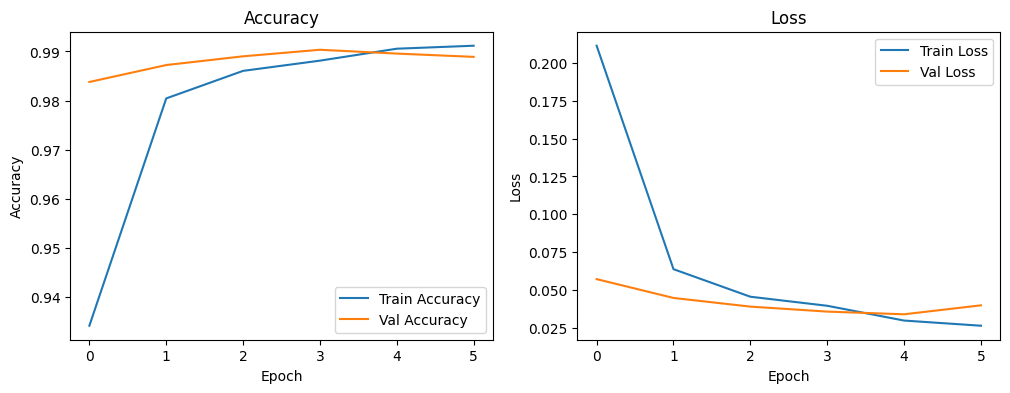

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = mnist.load_data()

np.random.seed(7)
X_train = X_train.astype('float32') / 255.0 + np.random.normal(0, 0.02, X_train.shape)
X_test = X_test.astype('float32') / 255.0 + np.random.normal(0, 0.02, X_test.shape)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(48, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(96, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(160, activation='relu'),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0015), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_train, y_train, validation_split=0.15, epochs=6, batch_size=128)
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
